In [1]:
# libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline
import random
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.offsetbox as offsetbox # for text box with position control
import pickle
import seaborn as sns

In [2]:
mochi_results = pd.read_csv("mochi/epistasis_summary.txt",
                            sep = "\t")

mochi_results

,n,total_possible_combinations,number_interactions_raw,number_interactions_1d,number_preserved_interactions_1d
0,1,25,24,23,23
1,2,217,203,155,150
2,3,1061,611,500,406
3,4,2335,950,824,701
4,5,2318,853,789,734
5,6,975,333,319,304
6,7,123,32,32,31


In [3]:
y1 = []

for i in range(mochi_results.shape[0]):
    if np.isnan(mochi_results["number_interactions_raw"][i]):
        break
    y1.append(mochi_results["number_interactions_raw"][i])

y2 = []

for i in range(mochi_results.shape[0]):
    if np.isnan(mochi_results["number_interactions_1d"][i]):
        break
    y2.append(mochi_results["number_interactions_1d"][i])

y3 = []

for i in range(mochi_results.shape[0]):
    if np.isnan(mochi_results["number_preserved_interactions_1d"][i]):
        break
    y3.append(mochi_results["number_preserved_interactions_1d"][i])

x = np.array([i for i in range(len(y1))])

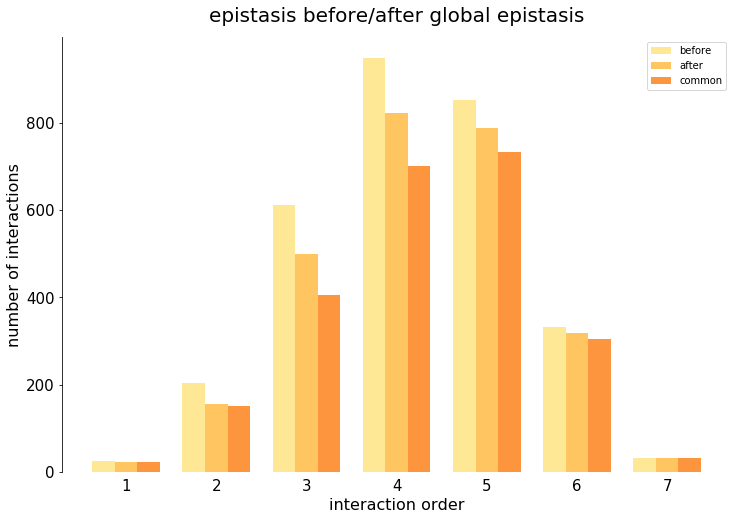

In [4]:
from matplotlib import cm
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


matplotlib.rcParams['axes.spines.left'] = True
matplotlib.rcParams['axes.spines.right'] = False
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.bottom'] = False
matplotlib.rcParams['xtick.bottom'] = False


width = 0.25

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)

ax.bar(x,
       y1,
       width = width,
       label = "before",
       color = cm.YlOrRd(np.linspace(0,1,20))[3])
ax.bar(x+width,
       y2,
       width = width,
       label = "after",
       color = cm.YlOrRd(np.linspace(0,1,20))[6])
ax.bar(x+width+width,
       y3,
       width = width,
       label = "common",
       color = cm.YlOrRd(np.linspace(0,1,20))[9])


# x axis
ax.set_xticks(np.arange(len(y1))+width)
ax.set_xticklabels(labels = [ str(i+1) for i in range(len(y1)) ])



ax.set_ylabel("number of interactions",
              fontsize = 16)

ax.set_xlabel("interaction order",
              fontsize = 16)

# tick font size
ax.tick_params(axis='both', which='major', labelsize=15)

ax.legend()

# title
ax.set_title("epistasis before/after global epistasis",
             fontsize = 20,
             pad = 15)


plt.savefig("010b_Epistasis_Before_After_Common_AbsNumbers.pdf", transparent=True)